<a href="https://colab.research.google.com/github/Raishaaam/infrastruktur-dan-platform-untuk-sains-data-assigment/blob/main/MODUL%204/Tugas_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Raisha Amalia**                                                                       
**2311110002**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from imblearn.over_sampling import SMOTE

Load Data

In [ ]:
train_features = pd.read_csv('train_features1.csv')
train_labels = pd.read_csv('train_features2.csv')
train = pd.concat([train_features, train_labels], axis=1)

EDA (Exploratory Data Analysis)

Menampilkan Informasi Tentang Nama Kolom dan Jumlah Non-Null, Index Range, dll.

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tahun_kelahiran          3817 non-null   float64
 1   pendidikan               3628 non-null   object 
 2   status_pernikahan        3605 non-null   object 
 3   pendapatan               3627 non-null   float64
 4   jumlah_anak_balita       3627 non-null   float64
 5   jumlah_anak_remaja       3613 non-null   float64
 6   terakhir_belanja         3645 non-null   float64
 7   belanja_buah             3636 non-null   float64
 8   belanja_daging           3639 non-null   float64
 9   belanja_ikan             3624 non-null   float64
 10  belanja_kue              3603 non-null   float64
 11  pembelian_diskon         3639 non-null   float64
 12  pembelian_web            3652 non-null   float64
 13  pembelian_toko           3648 non-null   float64
 14  keluhan                 

Kode ini digunakan untuk menampilkan sebuah informasi dasar mengenai sebuah DataFrame diatas. Hal ini dapat diketahui dari output program yang menampilkan sebuah nama kolom, jumlah data pada setiap kolom dan juga tipe data. Pada bagian bawah terdapat informasi tentang Memory Usage dengan 984.5+kb.

Menampilkan Informasi Terkait Mean, Max, Std, Min, dll

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
tahun_kelahiran,3817.0,1.967824e+03,1.176813e+01,1899.0,1959.00,1968.0,1.976000e+03,2.000000e+03
pendapatan,3627.0,1.144832e+08,4.346042e+07,5073000.0,81125122.00,115621394.0,1.504960e+08,3.328840e+08
jumlah_anak_balita,3627.0,2.930797e-01,4.730627e-01,0.0,0.00,0.0,1.000000e+00,2.000000e+00
jumlah_anak_remaja,3613.0,3.537227e-01,4.930139e-01,0.0,0.00,0.0,1.000000e+00,2.000000e+00
terakhir_belanja,3645.0,4.723155e+01,2.706851e+01,0.0,25.00,47.0,6.900000e+01,1.280000e+02
belanja_buah,3636.0,5.980424e+04,7.402498e+04,0.0,7907.00,26456.0,8.616200e+04,3.965080e+05
belanja_daging,3639.0,4.385748e+05,5.120427e+05,0.0,49479.50,221993.0,6.863555e+05,3.489675e+06
belanja_ikan,3624.0,8.142900e+04,9.997623e+04,0.0,10115.00,36054.5,1.213800e+05,6.216000e+05
belanja_kue,3603.0,6.337797e+04,7.943546e+04,0.0,7947.00,27795.0,8.950250e+04,5.421640e+05
pembelian_diskon,3639.0,2.125584e+00,2.100133e+00,0.0,0.00,2.0,3.000000e+00,2.000000e+01


Kode ini digunakan untuk menampilkan informasi terkait mean, max, std, min dan juga kuartil (23%, 50%, 75%) untuk setiap kolom pada dataframe "train".


Menampilkan Setiap Kolom

In [ ]:
train.columns

Index(['tahun_kelahiran', 'pendidikan', 'status_pernikahan', 'pendapatan',
       'jumlah_anak_balita', 'jumlah_anak_remaja', 'terakhir_belanja',
       'belanja_buah', 'belanja_daging', 'belanja_ikan', 'belanja_kue',
       'pembelian_diskon', 'pembelian_web', 'pembelian_toko', 'keluhan',
       'tanggal_menjadi_anggota', 'ID', 'tahun_kelahiran', 'pendidikan',
       'status_pernikahan', 'pendapatan', 'jumlah_anak_balita',
       'jumlah_anak_remaja', 'terakhir_belanja', 'belanja_buah',
       'belanja_daging', 'belanja_ikan', 'belanja_kue', 'pembelian_diskon',
       'pembelian_web', 'pembelian_toko', 'keluhan',
       'tanggal_menjadi_anggota'],
      dtype='object')

# Visualisasi Data

Perbandingan pada Variabel Pendidikan

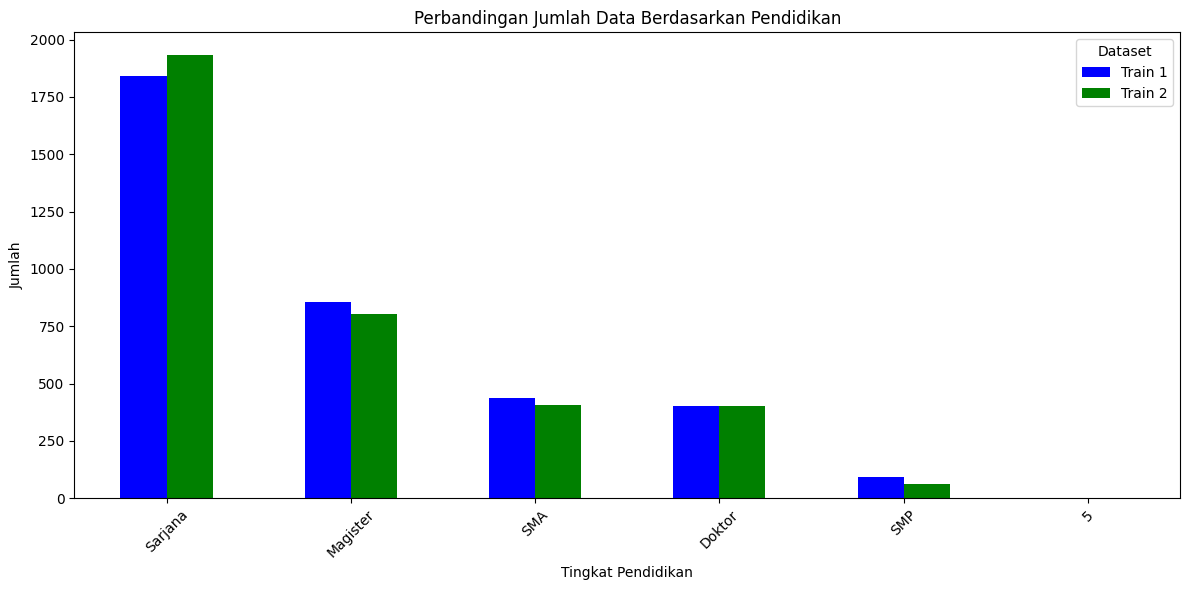

In [ ]:
data1 = pd.read_csv('train_features1.csv')
data2 = pd.read_csv('train_features2.csv')
pendidikan_counts1 = data1['pendidikan'].value_counts()
pendidikan_counts2 = data2['pendidikan'].value_counts()

comparison = pd.DataFrame({
    'Train 1': pendidikan_counts1,
    'Train 2': pendidikan_counts2
}).fillna(0)
comparison.plot(kind='bar', figsize=(12, 6), color=['blue', 'green'])

plt.title('Perbandingan Jumlah Data Berdasarkan Pendidikan')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

Kode ini digunakan untuk menampilkan perbandingan jumlah variabel "pendidikan" antara dua dataset yaitu (`train_features1`, `train_features2`). Kode ini juga bertujuan untuk memberikan visualisasi yang jelas dari perbandingan jumlah pendidikan antara dua dataset, dapat kita lihat pada grafik batang variabel sarjana, data ke 2(orange) memiliki nilai yang lebih tinggi dibandingkan dengan dataset yang pertama. Pada grafik, dapat dilihat bahwa untuk kategori sarjana memiliki nilai yang lebih tinggi dibandingkan variabel lainnya, dan yang paling rendahnya adalah kategori SMP untuk setiap data.

Perbandingan pada Variabel Status Menikah

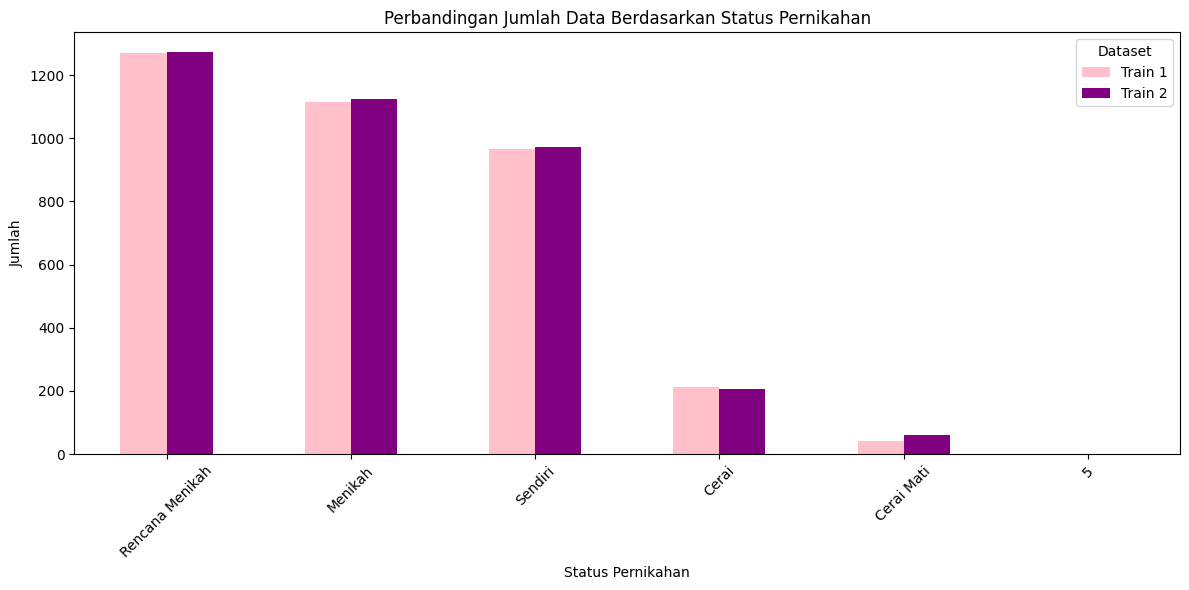

In [ ]:
data1 = pd.read_csv('train_features1.csv')
data2 = pd.read_csv('train_features2.csv')

status_counts1 = data1['status_pernikahan'].value_counts()
status_counts2 = data2['status_pernikahan'].value_counts()
comparison = pd.DataFrame({
    'Train 1': status_counts1,
    'Train 2': status_counts2
}).fillna(0)

comparison.plot(kind='bar', figsize=(12, 6), color=['pink', 'purple'])

plt.title('Perbandingan Jumlah Data Berdasarkan Status Pernikahan')
plt.xlabel('Status Pernikahan')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

Kode ini digunakan untuk menampilkan perbandingan jumlah variabel "Status Menikah" antara dua dataset yaitu (`train_features1`, `train_features2`). Kode ini juga bertujuan untuk memberikan visualisasi yang jelas dari perbandingan jumlah pendidikan antara dua dataset, dapat kita lihat pada grafik batang dalam variabel Rencana Menikah pada dataset "Train 2" memiliki jumlah data yang paling banyak dibandingkan dengan dataset "Train 1"(pink). Jika dilihat pada variabel "Cerai Mati", baik dataset "Train 1" maupun "Train 2" memiliki jumlah data terendah dibandingkan kategori status pernikahan lainnya.

Perbandingan antara variabel Pembelian Web dan Pembelian Toko pada setiap dataset

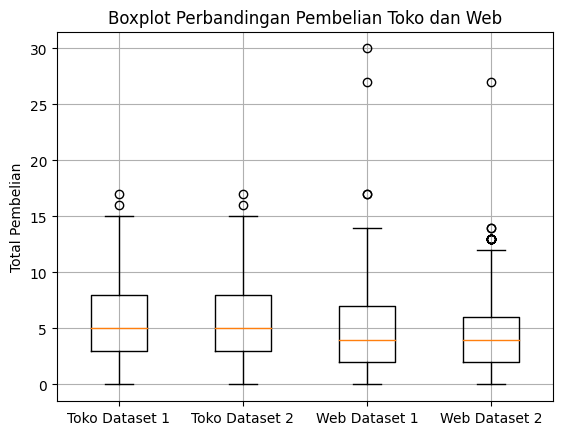

In [ ]:
data1 = pd.read_csv('train_features1.csv')
data2 = pd.read_csv('train_features2.csv')
data = [
    data1['pembelian_toko'].dropna(),
    data2['pembelian_toko'].dropna(),
    data1['pembelian_web'].dropna(),
    data2['pembelian_web'].dropna()
]

plt.boxplot(data, labels=['Toko Dataset 1', 'Toko Dataset 2', 'Web Dataset 1', 'Web Dataset 2'])
plt.title('Boxplot Perbandingan Pembelian Toko dan Web')
plt.ylabel('Total Pembelian')
plt.grid()
plt.show()

Kode ini digunakan untuk menampilkan perbandingan jumlah variabel "Pembelian Web" dan "Pembelian Toko" antara dua dataset (`train_features1`, `train_features2`). Pada variabel `Pembelian Toko`dataset 1 "train 1" memiliki median pembelian toko yang lebih rendah dibandingkan dataset 2(train 2). Hal ini menunjukkan bahwa total pembelian toko di dataset 1 cenderung lebih rendah dan rentang nilai pembelian pada dataset 1 lebih kecil. Lalu pada dataset 2 memiliki beberapa nilai pembelian toko yang lebih tinggi, hal ini dapar dilihat pada nilai outlier yang berada di atas kotak.

Lalu pada median dataset 1 dan dataset 2 terlihat sama, hal ini menunjukkan bahwa secara umum pembelian web tidak terlalu berbeda secara signifikan antara kedua dataset, tetapi rentang nilai pembelian web di Dataset 2 kali lebih lebar.

Perbedaan Tahun Kelahiran antar 2 Dataset

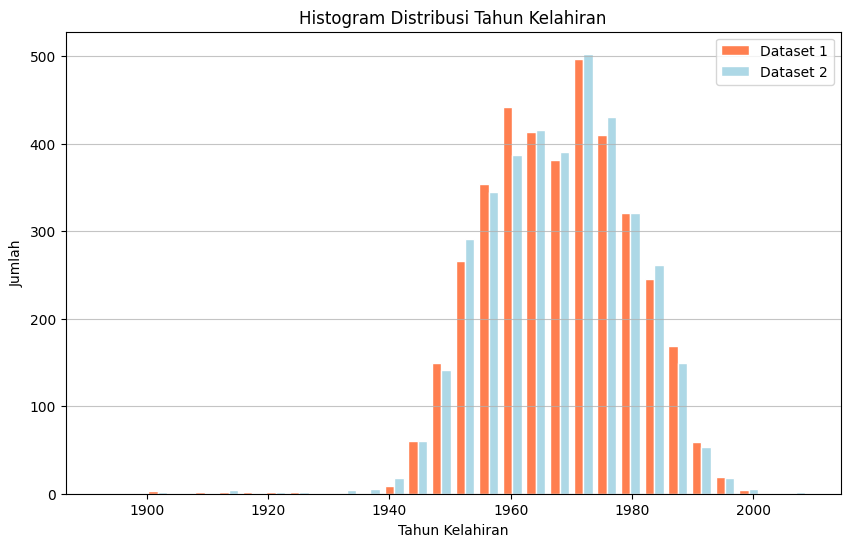

In [ ]:
data1 = pd.read_csv('train_features1.csv')
data2 = pd.read_csv('train_features2.csv')

plt.figure(figsize=(10, 6))
plt.hist([data1['tahun_kelahiran'].dropna(), data2['tahun_kelahiran'].dropna()],
         bins=30, color=['coral', 'lightblue'], edgecolor='white',
         label=['Dataset 1', 'Dataset 2'])
plt.title('Histogram Distribusi Tahun Kelahiran')
plt.xlabel('Tahun Kelahiran')
plt.ylabel('Jumlah')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Kode ini digunakan untuk menampilkan perbandingan jumlah variabel "Tahun Kelahiran" antara dua dataset yaitu (`train_features1`, `train_features2`). Pada histogram menunjukkan pola distribusi tahun kelahiran yang mirip antara dataset 1 dan dataset 2. Terlihat puncak distribusi yang tinggi disekitaran tahun 1960-1980, hal ini menunjukkan bahwa tahun kelahiran terbanyak berada pada sekitar tahun tersebut. Lalu sebelum dan sesudah tahun 1960-1980, terjadi penurunan jumlah distribusi tahun kelahiran secara bertahap.

Perbandingan Variabel "Belanja Daging" dan "Belanja Ikan" pada dua dataset

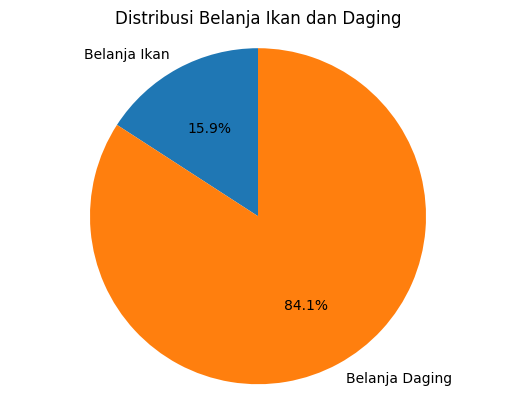

In [ ]:
data = pd.read_csv('train_features1.csv')
data = pd.read_csv('train_features2.csv')
sizes = [data['belanja_ikan'].sum(), data['belanja_daging'].sum()]
labels = ['Belanja Ikan', 'Belanja Daging']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Distribusi Belanja Ikan dan Daging')
plt.show()

Kode ini digunakan untuk menampilkan perbandingan jumlah variabel "Belanja Daging" dan "Belanja Ikan" antara dua dataset yaitu (`train_features1`, `train_features2`). Pada pie chart menunjukkan bahwa 84,1% dari total belanja adalah untuk belanja daging, sedangkan 15,9& adalah untuk belanja ikan. Hal ini memberikan gambaran tentang komposisi belanja antar dua variabel.

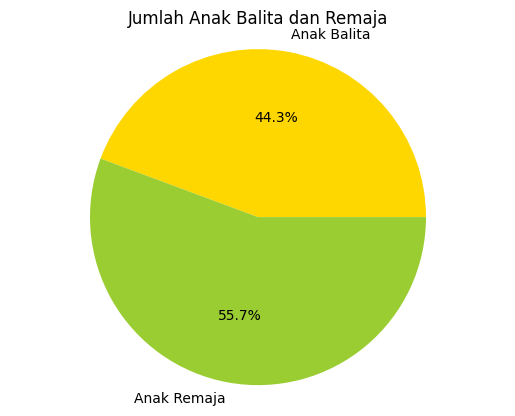

In [ ]:
df = pd.read_csv('train_features1.csv')
df = pd.read_csv('train_features2.csv')

sizes = [df['jumlah_anak_balita'].sum(), df['jumlah_anak_remaja'].sum()]
labels = ['Anak Balita', 'Anak Remaja']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['gold', 'yellowgreen'])
plt.axis('equal')
plt.title('Jumlah Anak Balita dan Remaja')
plt.show()

Kode ini digunakan untuk menampilkan perbandingan jumlah variabel "Jumlah Anak Balita" dan "Jumlah Anak Remaja" antara dua dataset yaitu (`train_features1`, `train_features2`). Pada pie chart menunjukkan bahwa 55.7% adalah total dari jumlah anak remaja, sedangkan 44.3& adalah total dari jumlah anak balita. Hal ini dapat disimpulkan bahwa jumlah nilai variabel "Jumlah Anak Remaha" lebih banyaj daripada "Jumlah Anak Balita" hal ini didapatkan dari kedua dataset.

# apakah terdapat perbedaan karakteristik data train pada praktikum sebelumnya?

Ya, terdapat perbedaan karakteristik pada data, dapat disimpulkan bahwa data `train features1` memiliki informasi yang lebih lengkap dan juga lebih bervariasi dibandingkan `data features2`. Data `train features1` memiliki variasi nilai yang lebih banyak daripada data 1 `train features2`.